# Medicaid Expansion and Employer-Sponsored Insurance Premiums

DML analysis using Form 5500 data, 2001-2023.

## 1. Background

This notebook estimates the effect of Medicaid expansion on employer-sponsored health insurance premiums. We use a staggered treatment design (41 states expanded between 2014-2023, 10 never expanded) and compare TWFE DiD with Double/Debiased Machine Learning (Chernozhukov et al. 2018). See the accompanying paper for full discussion.

## 2. Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.dpi': 150
})

df = pd.read_csv('../Datasets/dml_analysis_data.csv')
print(df.shape, f'| {df["state"].nunique()} states | {df["year"].min()}-{df["year"].max()}')

(1173, 50) | 51 states | 2001-2024


In [21]:
# Expansion timing (CRS IF10399, KFF, advisory.com)
EXPANSION_YEARS = {
    'AZ': 2014, 'AR': 2014, 'CA': 2014, 'CO': 2014, 'CT': 2014,
    'DE': 2014, 'DC': 2014, 'HI': 2014, 'IL': 2014, 'IA': 2014,
    'KY': 2014, 'MD': 2014, 'MA': 2014, 'MN': 2014, 'NV': 2014,
    'NJ': 2014, 'NM': 2014, 'NY': 2014, 'ND': 2014, 'OH': 2014,
    'OR': 2014, 'RI': 2014, 'VT': 2014, 'WA': 2014, 'WV': 2014,
    'MI': 2014, 'NH': 2014,
    'PA': 2015, 'IN': 2015, 'AK': 2015,
    'MT': 2016, 'LA': 2016,
    'VA': 2019, 'ME': 2019,
    'ID': 2020, 'UT': 2020, 'NE': 2020,
    'MO': 2021, 'OK': 2021,
    'NC': 2023, 'SD': 2023,
}
NEVER_EXPANDED = ['AL', 'FL', 'GA', 'KS', 'MS', 'SC', 'TN', 'TX', 'WI', 'WY']

df['expansion_year'] = df['state'].map(EXPANSION_YEARS)
df['medicaid_expansion'] = (
    df['expansion_year'].notna() & (df['year'] >= df['expansion_year'])
).astype(int)
df['event_time'] = df['year'] - df['expansion_year']
df['expansion_cohort'] = df['expansion_year'].fillna(0).astype(int)

ever_expanded = df.groupby('state')['expansion_year'].first().notna().astype(int).reset_index()
ever_expanded.columns = ['state', 'ever_expanded']

print(f'{len(EXPANSION_YEARS)} expansion states, {len(NEVER_EXPANDED)} never-expanded')
print(f'Treated state-years: {df["medicaid_expansion"].sum()}, control: {(df["medicaid_expansion"]==0).sum()}')
print(df.groupby('expansion_cohort')['state'].nunique())

41 expansion states, 10 never-expanded
Treated state-years: 384, control: 789
expansion_cohort
0       10
2014    27
2015     3
2016     2
2019     2
2020     3
2021     2
2023     2
Name: state, dtype: int64


In [22]:
# Table 2: Expansion cohort table
cohort_table = []
cohort_states = {}
for st, yr in sorted(EXPANSION_YEARS.items(), key=lambda x: (x[1], x[0])):
    cohort_states.setdefault(yr, []).append(st)

for yr in sorted(cohort_states.keys()):
    sts = cohort_states[yr]
    cohort_table.append({'Cohort': yr, 'States': ', '.join(sts), 'N': len(sts)})
cohort_table.append({'Cohort': 'Never', 'States': ', '.join(sorted(NEVER_EXPANDED)), 'N': len(NEVER_EXPANDED)})

ct = pd.DataFrame(cohort_table)
print('Table 2: Medicaid Expansion Cohorts')
print(ct.to_string(index=False))
print(f'Total: {sum(r["N"] for r in cohort_table)} states + DC')

Table 2: Medicaid Expansion Cohorts
Cohort                                                                                                     States  N
  2014 AR, AZ, CA, CO, CT, DC, DE, HI, IA, IL, KY, MA, MD, MI, MN, ND, NH, NJ, NM, NV, NY, OH, OR, RI, VT, WA, WV 27
  2015                                                                                                 AK, IN, PA  3
  2016                                                                                                     LA, MT  2
  2019                                                                                                     ME, VA  2
  2020                                                                                                 ID, NE, UT  3
  2021                                                                                                     MO, OK  2
  2023                                                                                                     NC, SD  2
 Never                      

In [23]:
# Table 1: Summary statistics by expansion status
outcome_vars = ['mean_log_premium_exp', 'mean_premium_exp', 'n_plans_exp',
                'mean_log_premium_nonexp', 'mean_premium_nonexp', 'n_plans_nonexp']

def summary_block(data, label):
    s = data[outcome_vars].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
    s.columns = ['N', 'Mean', 'SD', 'Min', 'Median', 'Max']
    s.index.name = label
    return s.round(2)

full = summary_block(df, 'Full Sample')
exp = summary_block(df[df.merge(ever_expanded, on='state')['ever_expanded'] == 1], 'Expansion States')
nexp = summary_block(df[df.merge(ever_expanded, on='state')['ever_expanded'] == 0], 'Never-Expansion')

print('Table 1: Summary Statistics (State-Year Level)')
print()
for label, tbl in [('Full Sample', full), ('Expansion States', exp), ('Never-Expansion States', nexp)]:
    print(f'--- {label} ---')
    print(tbl.to_string())
    print()

full.to_csv('../Results/tables/summary_statistics.csv')

Table 1: Summary Statistics (State-Year Level)

--- Full Sample ---
                              N     Mean       SD     Min   Median       Max
Full Sample                                                                 
mean_log_premium_exp     1173.0     6.55     0.46    5.15     6.51      7.91
mean_premium_exp         1173.0  1805.25   860.18  256.02  1627.50   5392.72
n_plans_exp              1173.0   435.47   467.73    5.00   305.00   3370.00
mean_log_premium_nonexp  1173.0     5.96     0.24    5.11     5.95      6.86
mean_premium_nonexp      1173.0  1073.90   323.12  349.25  1047.47   2675.88
n_plans_nonexp           1173.0  3687.39  4599.19   83.00  2165.00  31379.00

--- Expansion States ---
                             N     Mean       SD     Min   Median       Max
Expansion States                                                           
mean_log_premium_exp     943.0     6.47     0.40    5.53     6.43      7.79
mean_premium_exp         943.0  1676.69   742.59  369.55  1548

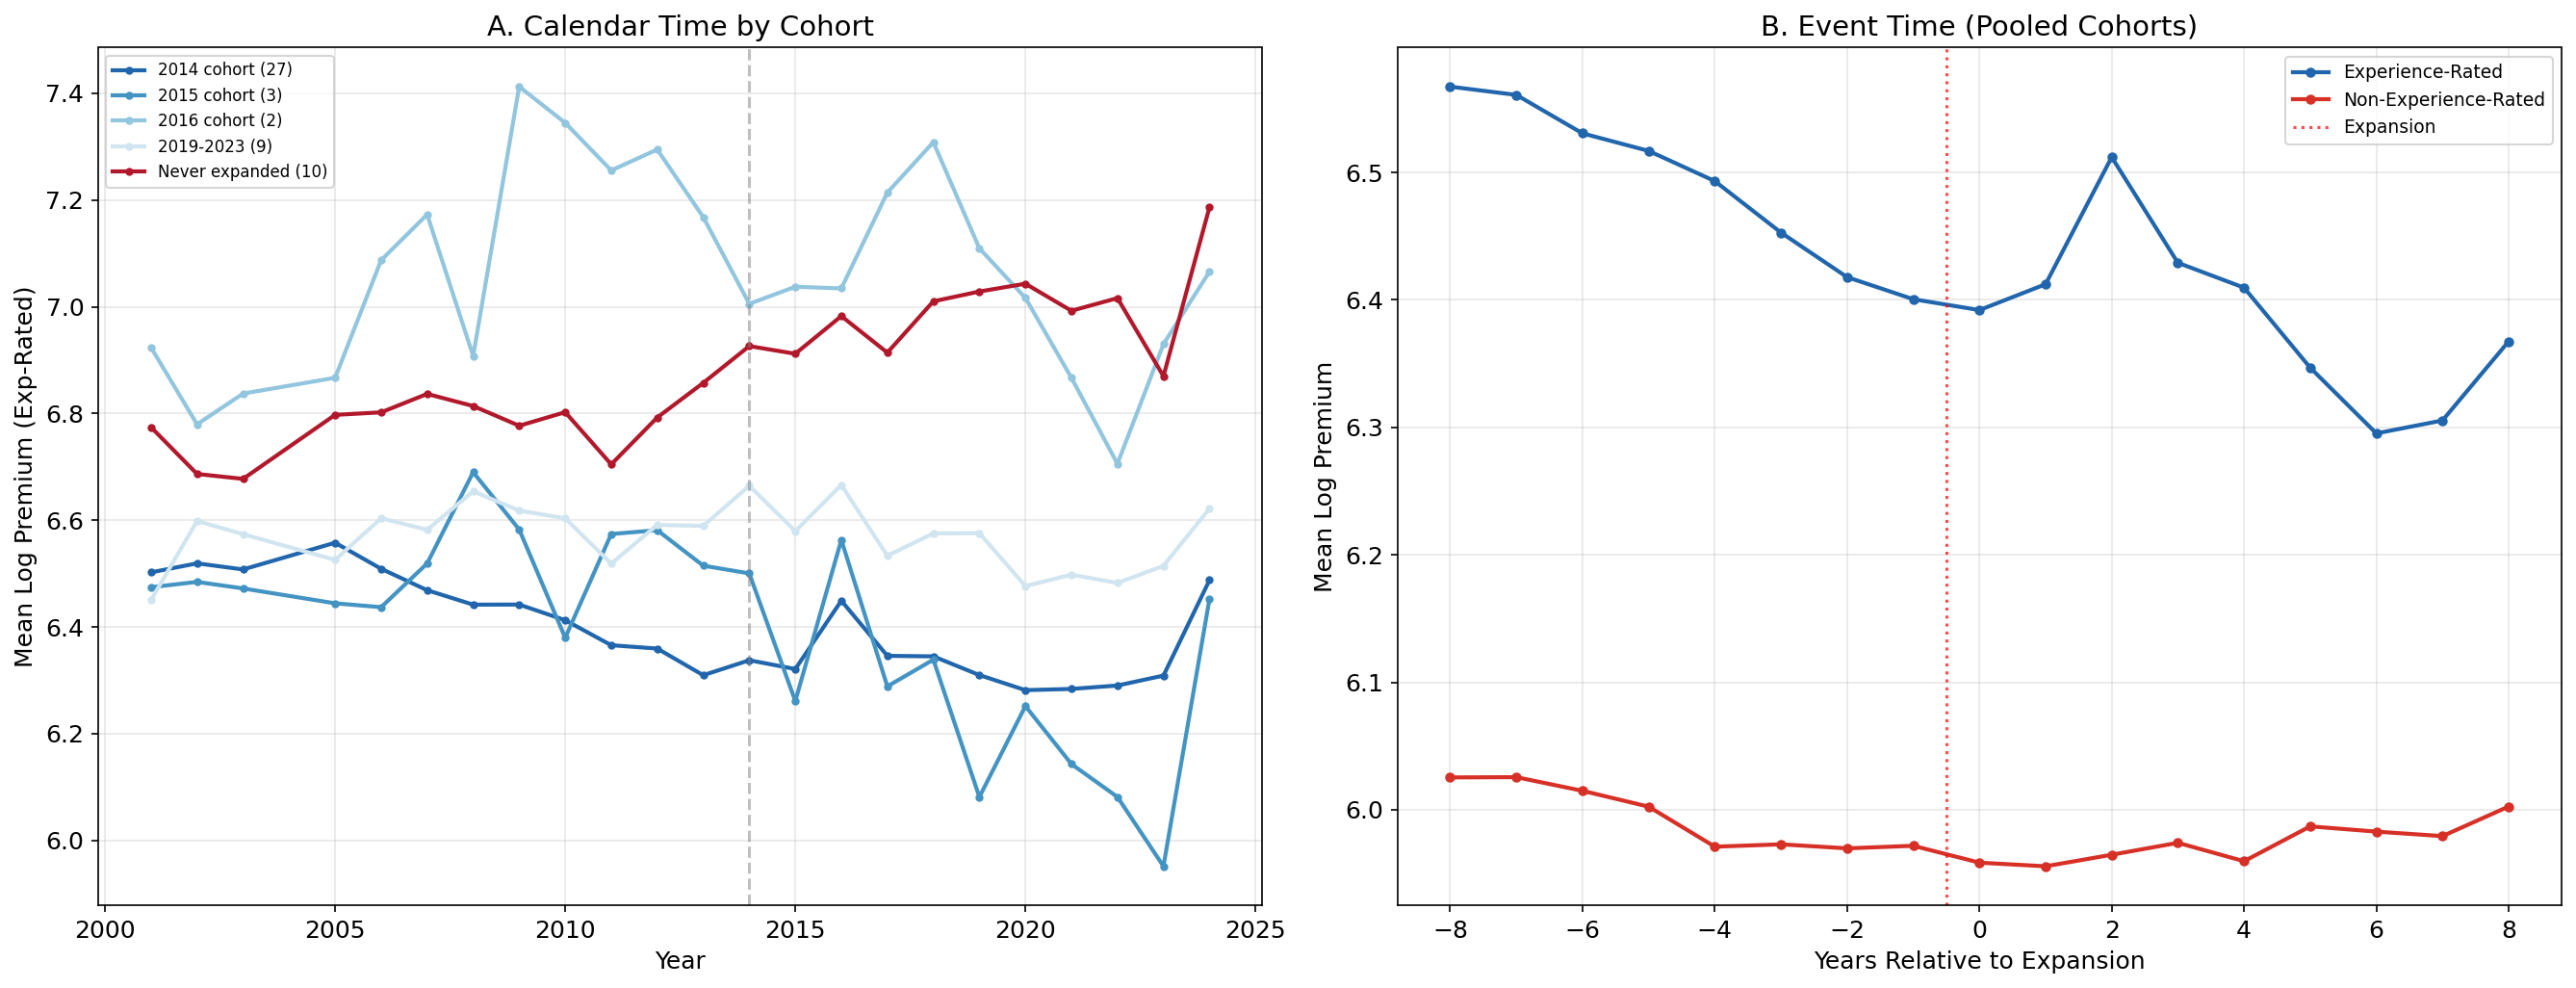

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: by expansion cohort
ax = axes[0]
cohort_colors = {
    2014: ('#2166ac', '2014 cohort (27)'),
    2015: ('#4393c3', '2015 cohort (3)'),
    2016: ('#92c5de', '2016 cohort (2)'),
    'later': ('#d1e5f0', '2019-2023 (9)'),
    0: ('#b2182b', 'Never expanded (10)'),
}
df['cohort_group'] = df['expansion_cohort'].apply(
    lambda x: x if x in [2014, 2015, 2016, 0] else ('later' if x > 0 else 0)
)
for cohort, (color, label) in cohort_colors.items():
    mask = df['cohort_group'] == cohort
    if mask.sum() == 0:
        continue
    ts = df[mask].groupby('year')['mean_log_premium_exp'].mean()
    ax.plot(ts.index, ts.values, 'o-', color=color, label=label, linewidth=2, markersize=3)
ax.axvline(x=2014, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Mean Log Premium (Exp-Rated)')
ax.set_title('A. Calendar Time by Cohort')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

# Panel B: event time
ax = axes[1]
exp_df = df[df['expansion_year'].notna()].copy()
exp_df['et_bin'] = exp_df['event_time'].clip(-8, 8).astype(int)
for y_col, label, color in [
    ('mean_log_premium_exp', 'Experience-Rated', '#2166ac'),
    ('mean_log_premium_nonexp', 'Non-Experience-Rated', '#d73027'),
]:
    ts = exp_df.groupby('et_bin')[y_col].mean()
    ax.plot(ts.index, ts.values, 'o-', color=color, label=label, linewidth=2, markersize=4)
ax.axvline(x=-0.5, color='red', linestyle=':', alpha=0.7, label='Expansion')
ax.set_xlabel('Years Relative to Expansion')
ax.set_ylabel('Mean Log Premium')
ax.set_title('B. Event Time (Pooled Cohorts)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/figures/premium_trends_staggered.png', dpi=150, bbox_inches='tight')
plt.show()

Table 3: Pre-2014 Covariate Balance
                      Variable  Exp Mean  Non-Exp Mean  Std Diff
             unemployment_rate     6.076         6.466    -0.184
       median_household_income 51844.100     45317.978     0.929
                  poverty_rate    13.955        16.405    -0.752
              uninsurance_rate    13.064        16.215    -0.792
                    pct_65plus    13.157        13.101     0.030
                  pct_nh_white    71.757        67.935     0.259
healthcare_spending_per_capita  7119.057      6496.853     0.598


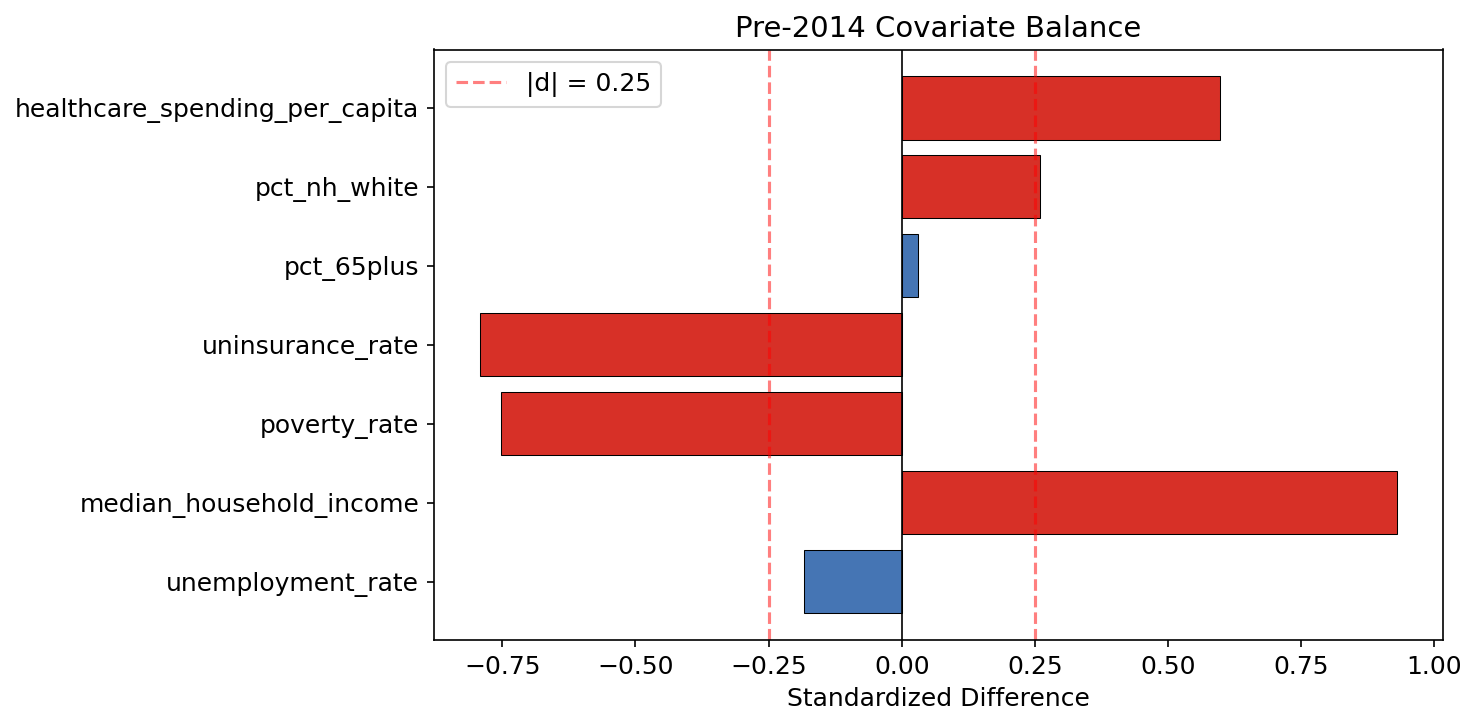

In [25]:
balance_vars = [
    'unemployment_rate', 'median_household_income', 'poverty_rate',
    'uninsurance_rate', 'pct_65plus', 'pct_nh_white',
    'healthcare_spending_per_capita'
]
balance_vars = [v for v in balance_vars if v in df.columns and df[v].notna().sum() > 0]

df_pre = df[df['year'] < 2014].merge(ever_expanded, on='state')

balance_data = []
for var in balance_vars:
    exp = df_pre[df_pre['ever_expanded'] == 1][var].dropna()
    non_exp = df_pre[df_pre['ever_expanded'] == 0][var].dropna()
    if len(exp) > 0 and len(non_exp) > 0:
        pooled_std = np.sqrt((exp.var() + non_exp.var()) / 2)
        std_diff = (exp.mean() - non_exp.mean()) / pooled_std if pooled_std > 0 else 0
        balance_data.append({
            'Variable': var, 'Exp Mean': exp.mean(),
            'Non-Exp Mean': non_exp.mean(), 'Std Diff': std_diff
        })

balance_df = pd.DataFrame(balance_data)
print('Table 3: Pre-2014 Covariate Balance')
print(balance_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if abs(x) > 0.25 else '#4575b4' for x in balance_df['Std Diff']]
ax.barh(balance_df['Variable'], balance_df['Std Diff'], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.25, color='red', linestyle='--', alpha=0.5, label='|d| = 0.25')
ax.axvline(x=-0.25, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Standardized Difference')
ax.set_title('Pre-2014 Covariate Balance')
ax.legend()
plt.tight_layout()
plt.savefig('../Results/figures/covariate_balance.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. TWFE DiD

Standard TWFE baseline: $\log(\text{Premium}_{st}) = \alpha_s + \gamma_t + \theta D_{st} + \varepsilon_{st}$, clustered at state level. Note TWFE bias under heterogeneous effects with staggered adoption (Goodman-Bacon 2021).

In [26]:
def run_twfe(data, y_col, d_col='medicaid_expansion', cluster_var='state'):
    subset = data.dropna(subset=[y_col, d_col]).copy()
    state_d = pd.get_dummies(subset['state'], prefix='st', drop_first=True, dtype=int)
    year_d = pd.get_dummies(subset['year'], prefix='yr', drop_first=True, dtype=int)
    X = sm.add_constant(pd.concat([subset[[d_col]], state_d, year_d], axis=1))
    y = subset[y_col]
    groups = subset[cluster_var].astype('category').cat.codes
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})
    ci = model.conf_int().loc[d_col]
    print(f'{y_col}: coef={model.params[d_col]:.4f}, SE={model.bse[d_col]:.4f}, '
          f'p={model.pvalues[d_col]:.4f}, CI=[{ci[0]:.4f}, {ci[1]:.4f}], '
          f'N={int(model.nobs)}, R2={model.rsquared:.4f}')
    return model

# covariates for DML
covariate_cols = [
    'unemployment_rate', 'median_household_income', 'population',
    'pct_65plus', 'pct_nh_white', 'poverty_rate', 'uninsurance_rate',
    'marketplace_SBM', 'pre_aca_guaranteed_issue',
    'healthcare_spending_per_capita'
]
year_dummy_cols = [c for c in df.columns if c.startswith('year_')]
x_cols_medicaid = [c for c in covariate_cols + year_dummy_cols if c in df.columns]

# full sample
print('--- Full sample ---')
twfe_exp_full = run_twfe(df, 'mean_log_premium_exp')
twfe_nonexp_full = run_twfe(df, 'mean_log_premium_nonexp')

# restricted to DML-comparable sample
dml_mask = df.dropna(subset=['mean_log_premium_exp', 'medicaid_expansion'] + x_cols_medicaid).index
df_dml_sample = df.loc[dml_mask].copy()
print(f'--- DML-comparable sample (N={len(df_dml_sample)}) ---')
twfe_exp_dml = run_twfe(df_dml_sample, 'mean_log_premium_exp')
twfe_nonexp_dml = run_twfe(df_dml_sample, 'mean_log_premium_nonexp')

--- Full sample ---
mean_log_premium_exp: coef=-0.1960, SE=0.0778, p=0.0118, CI=[-0.3486, -0.0434], N=1173, R2=0.7323
mean_log_premium_nonexp: coef=-0.0855, SE=0.0384, p=0.0259, CI=[-0.1607, -0.0103], N=1173, R2=0.7351
--- DML-comparable sample (N=550) ---
mean_log_premium_exp: coef=-0.1176, SE=0.0585, p=0.0444, CI=[-0.2322, -0.0030], N=550, R2=0.8765
mean_log_premium_nonexp: coef=-0.0468, SE=0.0215, p=0.0291, CI=[-0.0889, -0.0048], N=550, R2=0.9127


## 4. Event Study

Dynamic treatment effects in event time (relative to each state's expansion). Binned at $\pm5$, reference period $t=-1$.

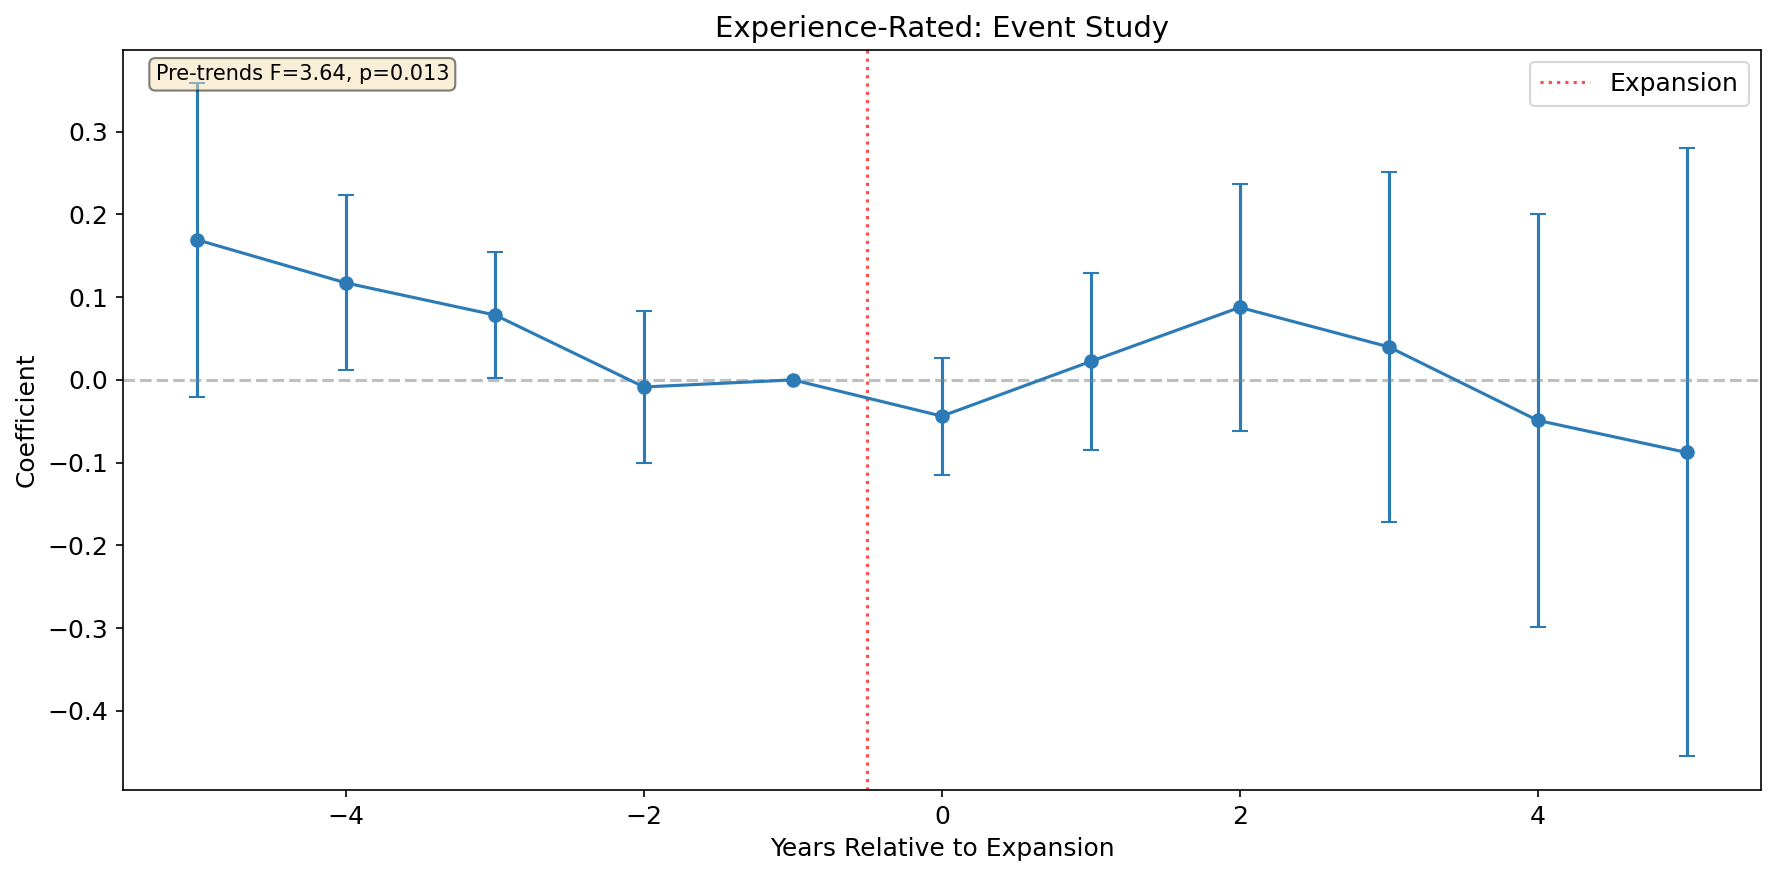

Pre-trends F=3.637, p=0.0128


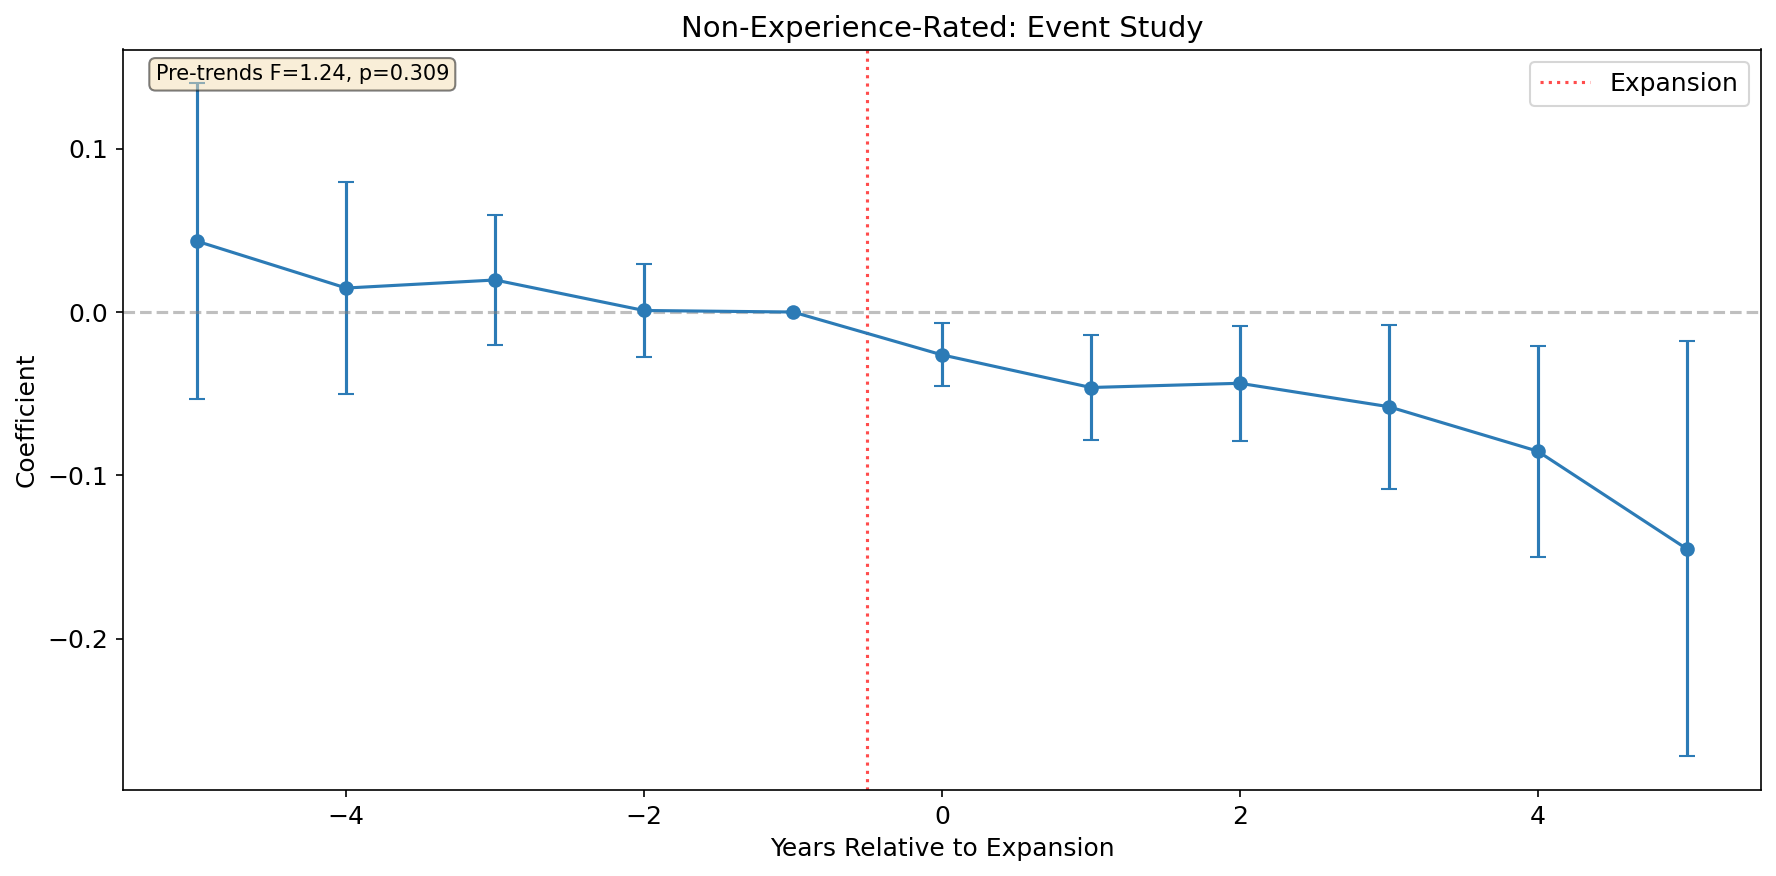

Pre-trends F=1.241, p=0.3092


In [27]:
def event_study_staggered(data, y_col, title, save_path):
    expanded = data[data['expansion_year'].notna()].dropna(subset=[y_col]).copy()
    expanded['et_bin'] = expanded['event_time'].clip(-5, 5).astype(int)
    ref = -1
    ets = sorted(expanded['et_bin'].unique())

    for et in ets:
        if et != ref:
            expanded[f'et_{et}'] = (expanded['et_bin'] == et).astype(int)
    et_cols = [f'et_{et}' for et in ets if et != ref]

    state_d = pd.get_dummies(expanded['state'], prefix='st', drop_first=True, dtype=int)
    year_d = pd.get_dummies(expanded['year'], prefix='yr', drop_first=True, dtype=int)
    X = sm.add_constant(pd.concat([expanded[et_cols], state_d, year_d], axis=1))
    y = expanded[y_col]
    groups = expanded['state'].astype('category').cat.codes
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})

    coefs = []
    for et in ets:
        if et == ref:
            coefs.append({'et': et, 'coef': 0, 'se': 0, 'lo': 0, 'hi': 0})
        else:
            col = f'et_{et}'
            coefs.append({'et': et, 'coef': model.params[col], 'se': model.bse[col],
                          'lo': model.conf_int().loc[col, 0], 'hi': model.conf_int().loc[col, 1]})
    cdf = pd.DataFrame(coefs)

    # pre-trends F-test
    pre_cols = [f'et_{et}' for et in ets if et < 0 and et != ref]
    if pre_cols:
        r_mat = np.zeros((len(pre_cols), len(model.params)))
        for i, col in enumerate(pre_cols):
            r_mat[i, list(model.params.index).index(col)] = 1
        ft = model.f_test(r_mat)
        f_stat, f_pval = float(ft.fvalue), float(ft.pvalue)
    else:
        f_stat, f_pval = np.nan, np.nan

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.errorbar(cdf['et'], cdf['coef'], yerr=[cdf['coef']-cdf['lo'], cdf['hi']-cdf['coef']],
                fmt='o-', capsize=4, color='#2c7bb6', markersize=6)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(-0.5, color='red', linestyle=':', alpha=0.7, label='Expansion')
    ax.set_xlabel('Years Relative to Expansion')
    ax.set_ylabel('Coefficient')
    ax.set_title(title)
    ax.legend()
    ax.text(0.02, 0.98, f'Pre-trends F={f_stat:.2f}, p={f_pval:.3f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Pre-trends F={f_stat:.3f}, p={f_pval:.4f}')
    return model, cdf

es_exp, es_exp_df = event_study_staggered(
    df, 'mean_log_premium_exp',
    'Experience-Rated: Event Study',
    '../Results/figures/event_study_exp_staggered.png')

es_nonexp, es_nonexp_df = event_study_staggered(
    df, 'mean_log_premium_nonexp',
    'Non-Experience-Rated: Event Study',
    '../Results/figures/event_study_nonexp_staggered.png')

## 5. DML Framework (Primary: Within-State Identification)

Partially linear model: $Y_{st} = \theta D_{st} + g(X_{st}) + \varepsilon_{st}$

DML partials out confounders from both $Y$ and $D$ using ML, then runs residual-on-residual regression. Cross-fitting prevents overfitting. See Chernozhukov et al. (2018, *Econometrics Journal*).

Our primary specification includes state dummy variables in the covariate vector, restricting identification to within-state variation. We also report pooled estimates without state FE for comparison.

## 6. DML Results: Primary (Within-State) and Pooled Specifications

In [28]:
import doubleml as dml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def run_dml(data, y_col, d_col, x_cols, label, n_folds=5, n_rep=5, state_fe=False):
    analysis_df = data.dropna(subset=[y_col, d_col] + x_cols).copy()

    if state_fe:
        state_dummies = pd.get_dummies(analysis_df['state'], prefix='st', drop_first=True, dtype=int)
        analysis_df = pd.concat([analysis_df, state_dummies], axis=1)
        expanded_x = x_cols + list(state_dummies.columns)
        use_x = expanded_x
    else:
        use_x = x_cols

    dml_data = dml.DoubleMLData(analysis_df, y_col=y_col, d_cols=d_col, x_cols=use_x)
    fe_tag = f' [+{len(use_x)-len(x_cols)} state dummies]' if state_fe else ''
    print(f'{label} | N={len(analysis_df)}, p={len(use_x)}{fe_tag}')

    learners = {
        'RF': (RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, n_jobs=-1, random_state=42),
               RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, n_jobs=-1, random_state=42)),
        'GBR': (GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=42),
                GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=42)),
        'Lasso': (Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))]),
                  Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))])),
    }

    results = {}
    for name, (ml_l, ml_m) in learners.items():
        try:
            np.random.seed(42)  # reproducible DML cross-fitting
            plr = dml.DoubleMLPLR(dml_data, ml_l=ml_l, ml_m=ml_m,
                                   n_folds=n_folds, n_rep=n_rep, score='partialling out')
            plr.fit()
            ci = plr.confint(level=0.95)
            try:
                y_r2 = 1 - np.var(plr.psi_elements['psi_b'][:, 0, :].mean(axis=1)) / np.var(analysis_df[y_col].values)
                d_r2 = 1 - np.var(plr.psi_elements['psi_a'][:, 0, :].mean(axis=1)) / np.var(analysis_df[d_col].values)
            except Exception:
                y_r2, d_r2 = np.nan, np.nan
            results[name] = {
                'coef': plr.coef[0], 'se': plr.se[0], 'pval': plr.pval[0],
                'ci_lower': ci.iloc[0, 0], 'ci_upper': ci.iloc[0, 1],
                'y_r2': y_r2, 'd_r2': d_r2, 'model': plr, 'n': len(analysis_df)
            }
            print(f'  {name}: coef={plr.coef[0]:.4f}, SE={plr.se[0]:.4f}, p={plr.pval[0]:.4f}')
        except Exception as e:
            print(f'  {name}: FAILED - {e}')
            results[name] = {'coef': np.nan, 'se': np.nan, 'pval': np.nan,
                              'ci_lower': np.nan, 'ci_upper': np.nan, 'n': len(analysis_df)}
    return results

In [29]:
print("-- With State FE --")
results_exp_primary = run_dml(df, 'mean_log_premium_exp', 'medicaid_expansion', x_cols_medicaid,
    'Experience-Rated (Primary: State FE)', state_fe=True)

print("\n-- Without State FE --")
results_exp_pooled = run_dml(df, 'mean_log_premium_exp', 'medicaid_expansion', x_cols_medicaid,
    'Experience-Rated (Pooled: No State FE)', state_fe=False)

# keep backward-compatible name for downstream cells
results_med_exp = results_exp_pooled

-- With State FE --
Experience-Rated (Primary: State FE) | N=550, p=81 [+49 state dummies]
  RF: coef=-0.2165, SE=0.0584, p=0.0002
  GBR: coef=-0.0719, SE=0.0513, p=0.1607
  Lasso: coef=-0.1067, SE=0.0411, p=0.0094

-- Without State FE --
Experience-Rated (Pooled: No State FE) | N=550, p=32
  RF: coef=-0.2665, SE=0.0561, p=0.0000
  GBR: coef=-0.2072, SE=0.0475, p=0.0000
  Lasso: coef=-0.3057, SE=0.0585, p=0.0000


In [30]:
print("-- With State FE --")
results_nonexp_primary = run_dml(df, 'mean_log_premium_nonexp', 'medicaid_expansion', x_cols_medicaid,
    'Non-Experience-Rated (Primary: State FE)', state_fe=True)

print("\n-- Without State FE --")
results_nonexp_pooled = run_dml(df, 'mean_log_premium_nonexp', 'medicaid_expansion', x_cols_medicaid,
    'Non-Experience-Rated (Pooled: No State FE)', state_fe=False)

results_med_nonexp = results_nonexp_pooled

-- With State FE --
Non-Experience-Rated (Primary: State FE) | N=550, p=81 [+49 state dummies]
  RF: coef=0.0073, SE=0.0177, p=0.6815
  GBR: coef=0.0113, SE=0.0150, p=0.4521
  Lasso: coef=-0.0248, SE=0.0127, p=0.0500

-- Without State FE --
Non-Experience-Rated (Pooled: No State FE) | N=550, p=32
  RF: coef=0.0115, SE=0.0181, p=0.5254
  GBR: coef=-0.0034, SE=0.0158, p=0.8296
  Lasso: coef=0.0262, SE=0.0224, p=0.2417


## 7. TWFE vs DML Comparison: Primary and Pooled

Same sample, comparing within-state (primary) and pooled identification.

In [31]:
rows = []
for label, twfe_m, dml_pri, dml_pool in [
    ('Exp-Rated', twfe_exp_dml, results_exp_primary, results_exp_pooled),
    ('NonExp-Rated', twfe_nonexp_dml, results_nonexp_primary, results_nonexp_pooled),
]:
    for ln in ['RF', 'GBR', 'Lasso']:
        r = dml_pri.get(ln, {})
        rows.append({'Outcome': label, 'Method': f'DML Primary ({ln})',
                     'Coef': r.get('coef', np.nan), 'SE': r.get('se', np.nan),
                     'p': r.get('pval', np.nan), 'Y_R2': r.get('y_r2', np.nan),
                     'D_R2': r.get('d_r2', np.nan)})
    for ln in ['RF', 'GBR', 'Lasso']:
        r = dml_pool.get(ln, {})
        rows.append({'Outcome': label, 'Method': f'DML Pooled ({ln})',
                     'Coef': r.get('coef', np.nan), 'SE': r.get('se', np.nan),
                     'p': r.get('pval', np.nan), 'Y_R2': r.get('y_r2', np.nan),
                     'D_R2': r.get('d_r2', np.nan)})
    rows.append({'Outcome': label, 'Method': 'TWFE',
                 'Coef': twfe_m.params['medicaid_expansion'],
                 'SE': twfe_m.bse['medicaid_expansion'],
                 'p': twfe_m.pvalues['medicaid_expansion'],
                 'Y_R2': np.nan, 'D_R2': np.nan})

comparison = pd.DataFrame(rows)
comparison.to_csv('../Results/tables/twfe_vs_dml_comparison.csv', index=False)
comparison.round(4)

,Outcome,Method,Coef,SE,p,Y_R2,D_R2
0,Exp-Rated,DML Primary (RF),-0.2165,0.0584,0.0002,0.9725,0.8943
1,Exp-Rated,DML Primary (GBR),-0.0719,0.0513,0.1607,0.9919,0.9216
2,Exp-Rated,DML Primary (Lasso),-0.1067,0.0411,0.0094,0.9803,0.9736
3,Exp-Rated,DML Pooled (RF),-0.2665,0.0561,0.0000,0.9696,0.8915
4,Exp-Rated,DML Pooled (GBR),-0.2072,0.0475,0.0000,0.9839,0.9001
5,Exp-Rated,DML Pooled (Lasso),-0.3057,0.0585,0.0000,0.9289,0.9247
6,Exp-Rated,TWFE,-0.1176,0.0585,0.0444,NaN,NaN
7,NonExp-Rated,DML Primary (RF),0.0073,0.0177,0.6815,0.9849,0.8943
8,NonExp-Rated,DML Primary (GBR),0.0113,0.0150,0.4521,0.9977,0.9216
9,NonExp-Rated,DML Primary (Lasso),-0.0248,0.0127,0.0500,0.9935,0.9736


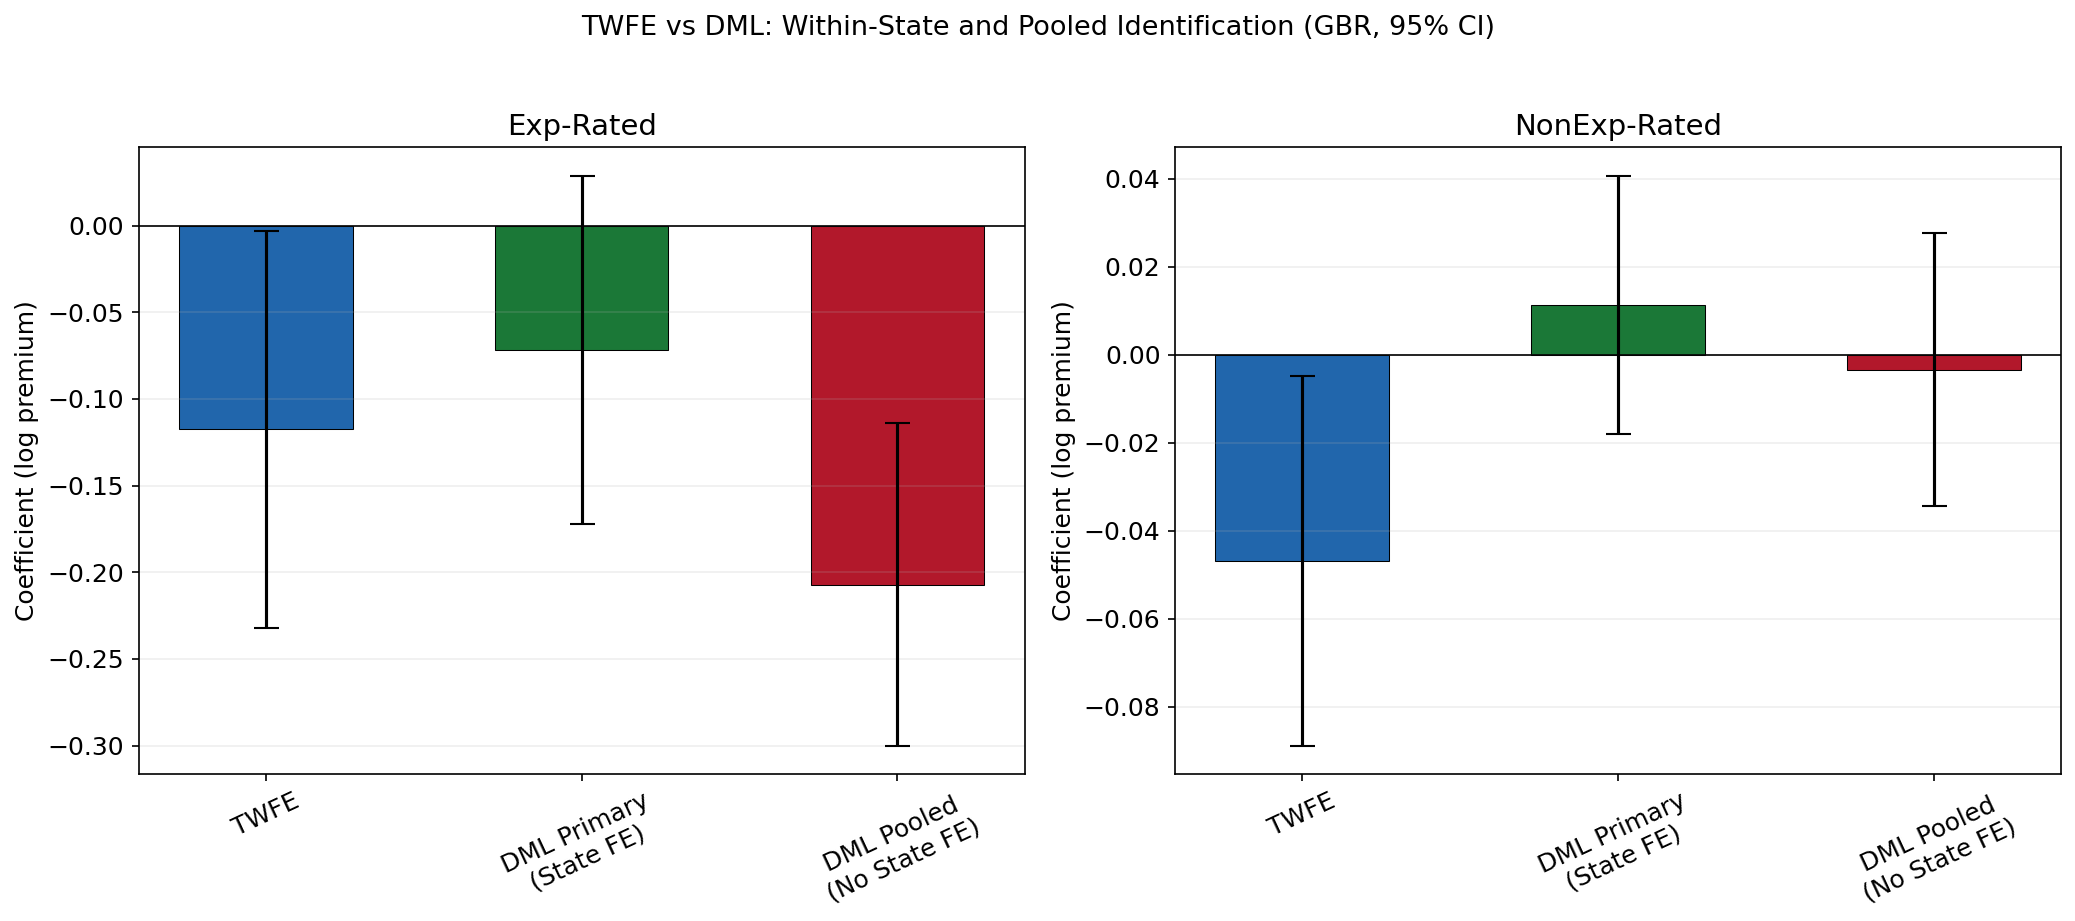

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, outcome, pri_r, pool_r, twfe_m in [
    (axes[0], 'Exp-Rated', results_exp_primary, results_exp_pooled, twfe_exp_dml),
    (axes[1], 'NonExp-Rated', results_nonexp_primary, results_nonexp_pooled, twfe_nonexp_dml),
]:
    labs = ['TWFE', 'DML Primary\n(State FE)', 'DML Pooled\n(No State FE)']
    cs = [twfe_m.params['medicaid_expansion'],
          pri_r.get('GBR', {}).get('coef', 0),
          pool_r.get('GBR', {}).get('coef', 0)]
    ss = [twfe_m.bse['medicaid_expansion'],
          pri_r.get('GBR', {}).get('se', 0),
          pool_r.get('GBR', {}).get('se', 0)]
    colors = ['#2166ac', '#1b7837', '#b2182b']
    bars = ax.bar(labs, cs, yerr=[1.96*s for s in ss], color=colors,
                  capsize=6, edgecolor='black', linewidth=0.5, width=0.55)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Coefficient (log premium)')
    ax.set_title(outcome)
    ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(axis='x', rotation=25)
plt.suptitle('TWFE vs DML: Within-State and Pooled Identification (GBR, 95% CI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../Results/figures/twfe_vs_dml_primary_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Pre-Trends Diagnosis

The event study F-test rejects parallel pre-trends for experience-rated premiums. We inspect which pre-period coefficients drive the rejection.

In [33]:
pre_exp = es_exp_df[es_exp_df['et'] < 0].copy()
pre_exp['sig'] = pre_exp.apply(lambda r: abs(r['coef']) > 1.96 * r['se'] if r['se'] > 0 else False, axis=1)
print('Pre-period coefficients (exp-rated):')
print(pre_exp.to_string(index=False))

pre_nonref = pre_exp[pre_exp['et'] != -1].sort_values('et')
if len(pre_nonref) > 1:
    slope = np.polyfit(pre_nonref['et'], pre_nonref['coef'], 1)[0]
    print(f'Linear trend slope: {slope:.4f}')
worst = pre_nonref.loc[pre_nonref['coef'].abs().idxmax()]
print(f'Largest: et={int(worst["et"])}, coef={worst["coef"]:.4f}')
print(f'Individually significant: {pre_exp["sig"].sum()}/{len(pre_exp)}')

print()
pre_ne = es_nonexp_df[es_nonexp_df['et'] < 0]
print('Pre-period coefficients (non-exp-rated):')
print(pre_ne.to_string(index=False))

Pre-period coefficients (exp-rated):
 et      coef       se        lo       hi   sig
 -5  0.169199 0.096574 -0.020082 0.358479 False
 -4  0.117070 0.053931  0.011368 0.222772  True
 -3  0.078357 0.038620  0.002662 0.154051  True
 -2 -0.008568 0.046843 -0.100379 0.083243 False
 -1  0.000000 0.000000  0.000000 0.000000 False
Linear trend slope: -0.0572
Largest: et=-5, coef=0.1692
Individually significant: 2/5

Pre-period coefficients (non-exp-rated):
 et     coef       se        lo       hi
 -5 0.043286 0.049368 -0.053474 0.140046
 -4 0.014688 0.033082 -0.050153 0.079528
 -3 0.019606 0.020314 -0.020209 0.059422
 -2 0.000939 0.014638 -0.027752 0.029630
 -1 0.000000 0.000000  0.000000 0.000000


## 9. Mechanism: Expansion and Uninsurance

If cost-shifting drives the premium effect, expansion should reduce uninsurance rates. We test this directly.

N=550, years 2009-2019
TWFE: coef=-1.2680, SE=0.4640, p=0.0063
DML:  coef=-1.6088, SE=0.2524, p=0.0000


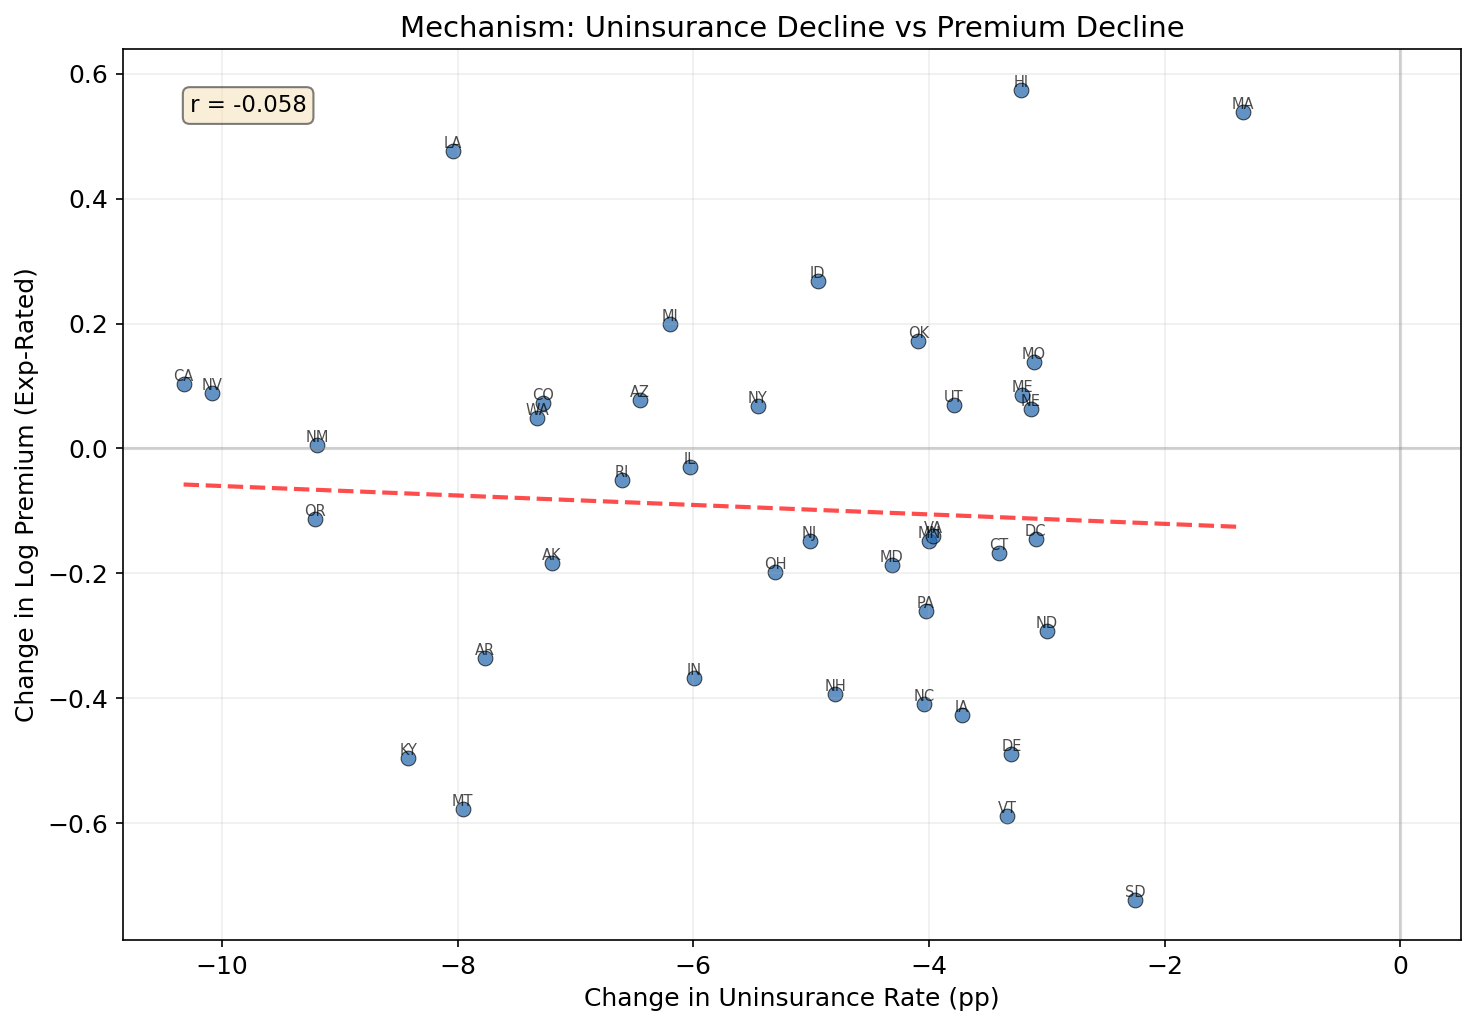

Correlation: -0.058


In [34]:
mechanism_x = [c for c in x_cols_medicaid if c != 'uninsurance_rate']
mech_df = df.dropna(subset=['uninsurance_rate', 'medicaid_expansion'] + mechanism_x).copy()
print(f'N={len(mech_df)}, years {mech_df["year"].min()}-{mech_df["year"].max()}')

# TWFE
st_d = pd.get_dummies(mech_df['state'], prefix='st', drop_first=True, dtype=int)
yr_d = pd.get_dummies(mech_df['year'], prefix='yr', drop_first=True, dtype=int)
X_m = sm.add_constant(pd.concat([mech_df[['medicaid_expansion']], st_d, yr_d], axis=1))
g_m = mech_df['state'].astype('category').cat.codes
twfe_unins = sm.OLS(mech_df['uninsurance_rate'], X_m).fit(cov_type='cluster', cov_kwds={'groups': g_m})
print(f'TWFE: coef={twfe_unins.params["medicaid_expansion"]:.4f}, '
      f'SE={twfe_unins.bse["medicaid_expansion"]:.4f}, p={twfe_unins.pvalues["medicaid_expansion"]:.4f}')

# DML
dml_d_u = dml.DoubleMLData(mech_df, y_col='uninsurance_rate', d_cols='medicaid_expansion', x_cols=mechanism_x)
np.random.seed(42)  # reproducible DML cross-fitting
dml_unins = dml.DoubleMLPLR(dml_d_u,
    ml_l=GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=42),
    ml_m=GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=42),
    n_folds=5, n_rep=5, score='partialling out')
dml_unins.fit()
print(f'DML:  coef={dml_unins.coef[0]:.4f}, SE={dml_unins.se[0]:.4f}, p={dml_unins.pval[0]:.4f}')

# scatter: state-level changes
expansion_states = df[df['expansion_year'].notna()]['state'].unique()
scatter_rows = []
for st in expansion_states:
    sd = df[df['state'] == st]
    ey = sd['expansion_year'].iloc[0]
    pre, post = sd[sd['year'] < ey], sd[sd['year'] >= ey]
    if len(pre) < 2 or len(post) < 2:
        continue
    vals = [pre['uninsurance_rate'].mean(), post['uninsurance_rate'].mean(),
            pre['mean_log_premium_exp'].mean(), post['mean_log_premium_exp'].mean()]
    if all(pd.notna(v) for v in vals):
        scatter_rows.append({'state': st, 'd_unins': vals[1]-vals[0], 'd_prem': vals[3]-vals[2]})

sdf = pd.DataFrame(scatter_rows)
if len(sdf) > 5:
    corr = sdf['d_unins'].corr(sdf['d_prem'])
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(sdf['d_unins'], sdf['d_prem'], c='#2166ac', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    for _, r in sdf.iterrows():
        ax.annotate(r['state'], (r['d_unins'], r['d_prem']), fontsize=7, alpha=0.7, ha='center', va='bottom')
    z = np.polyfit(sdf['d_unins'], sdf['d_prem'], 1)
    xl = np.linspace(sdf['d_unins'].min(), sdf['d_unins'].max(), 100)
    ax.plot(xl, np.poly1d(z)(xl), 'r--', alpha=0.7, linewidth=2)
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Change in Uninsurance Rate (pp)')
    ax.set_ylabel('Change in Log Premium (Exp-Rated)')
    ax.set_title('Mechanism: Uninsurance Decline vs Premium Decline')
    ax.axhline(0, color='gray', alpha=0.3); ax.axvline(0, color='gray', alpha=0.3)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('../Results/figures/mechanism_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Correlation: {corr:.3f}')

## 10. Dose-Response

States with higher pre-expansion uninsurance had more to gain from expansion. If cost-shifting drives the effect, the premium decline should be larger in those states.

High pre-unins (N=453): coef=-0.2607, SE=0.0529, p=0.0000
Low pre-unins (N=466): coef=-0.0693, SE=0.0681, p=0.3085


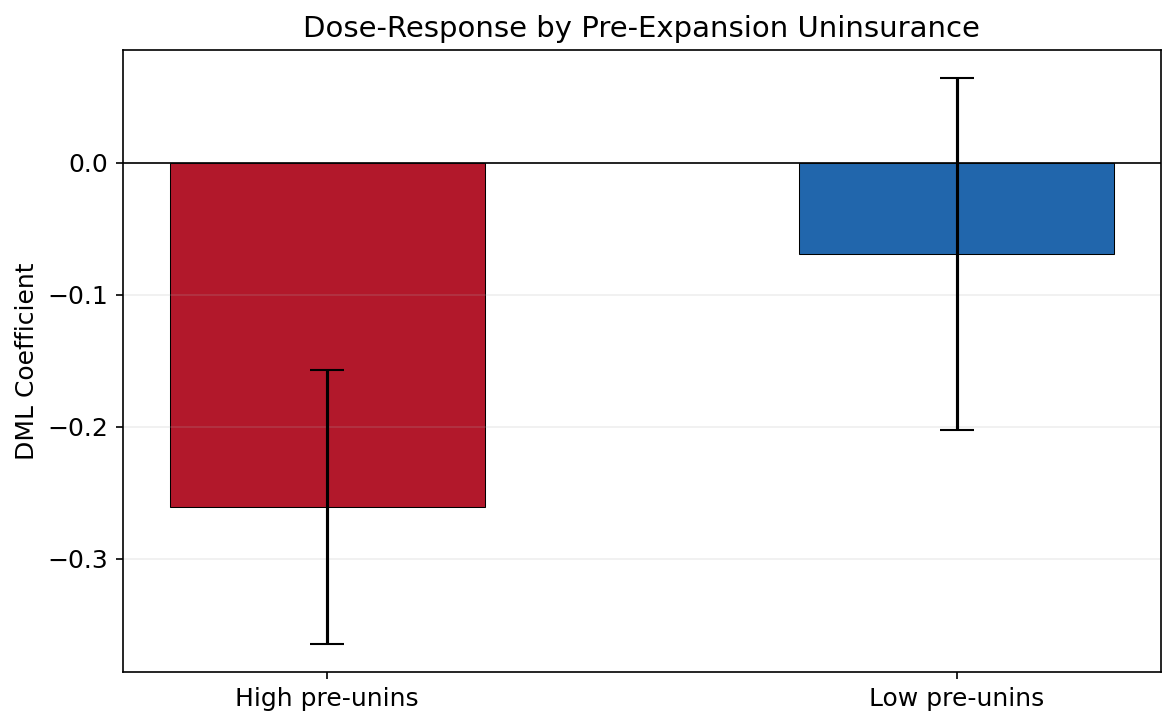

In [35]:
# pre-expansion uninsurance (2013 or nearest)
pre_u = df[df['year'] == 2013].set_index('state')['uninsurance_rate'].to_dict()
for st in df['state'].unique():
    if st not in pre_u or pd.isna(pre_u.get(st)):
        sp = df[(df['state'] == st) & (df['year'] < 2014) & df['uninsurance_rate'].notna()]
        if len(sp) > 0:
            pre_u[st] = sp.sort_values('year', ascending=False).iloc[0]['uninsurance_rate']
df['pre_unins'] = df['state'].map(pre_u)

med_u = df.loc[df['expansion_year'].notna(), 'pre_unins'].median()
df['high_dose'] = ((df['medicaid_expansion'] == 1) & (df['pre_unins'] > med_u)).astype(int)
df['low_dose'] = ((df['medicaid_expansion'] == 1) & (df['pre_unins'] <= med_u)).astype(int)

dose_results = {}
for label, col in [('High pre-unins', 'high_dose'), ('Low pre-unins', 'low_dose')]:
    keep = df['high_dose' if col == 'low_dose' else 'low_dose'] == 0
    d_df = df[keep].dropna(subset=['mean_log_premium_exp', col] + x_cols_medicaid)
    if len(d_df) < 50:
        print(f'{label}: too few obs ({len(d_df)})')
        continue
    dd = dml.DoubleMLData(d_df, y_col='mean_log_premium_exp', d_cols=col, x_cols=x_cols_medicaid)
    np.random.seed(42)  # reproducible DML cross-fitting
    m = dml.DoubleMLPLR(dd,
        ml_l=GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=42),
        ml_m=GradientBoostingRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, random_state=42),
        n_folds=5, n_rep=5, score='partialling out')
    m.fit()
    dose_results[label] = {'coef': m.coef[0], 'se': m.se[0], 'pval': m.pval[0]}
    print(f'{label} (N={len(d_df)}): coef={m.coef[0]:.4f}, SE={m.se[0]:.4f}, p={m.pval[0]:.4f}')

if len(dose_results) == 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    labs = list(dose_results.keys())
    cs = [dose_results[l]['coef'] for l in labs]
    ss = [dose_results[l]['se'] for l in labs]
    ax.bar(labs, cs, yerr=[1.96*s for s in ss], color=['#b2182b', '#2166ac'],
           capsize=8, edgecolor='black', linewidth=0.5, width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('DML Coefficient')
    ax.set_title('Dose-Response by Pre-Expansion Uninsurance')
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig('../Results/figures/dose_response.png', dpi=150, bbox_inches='tight')
    plt.show()

High Pre-Uninsurance: pre-trends F=5.864, p=0.0030
Low Pre-Uninsurance: pre-trends F=1.273, p=0.3154


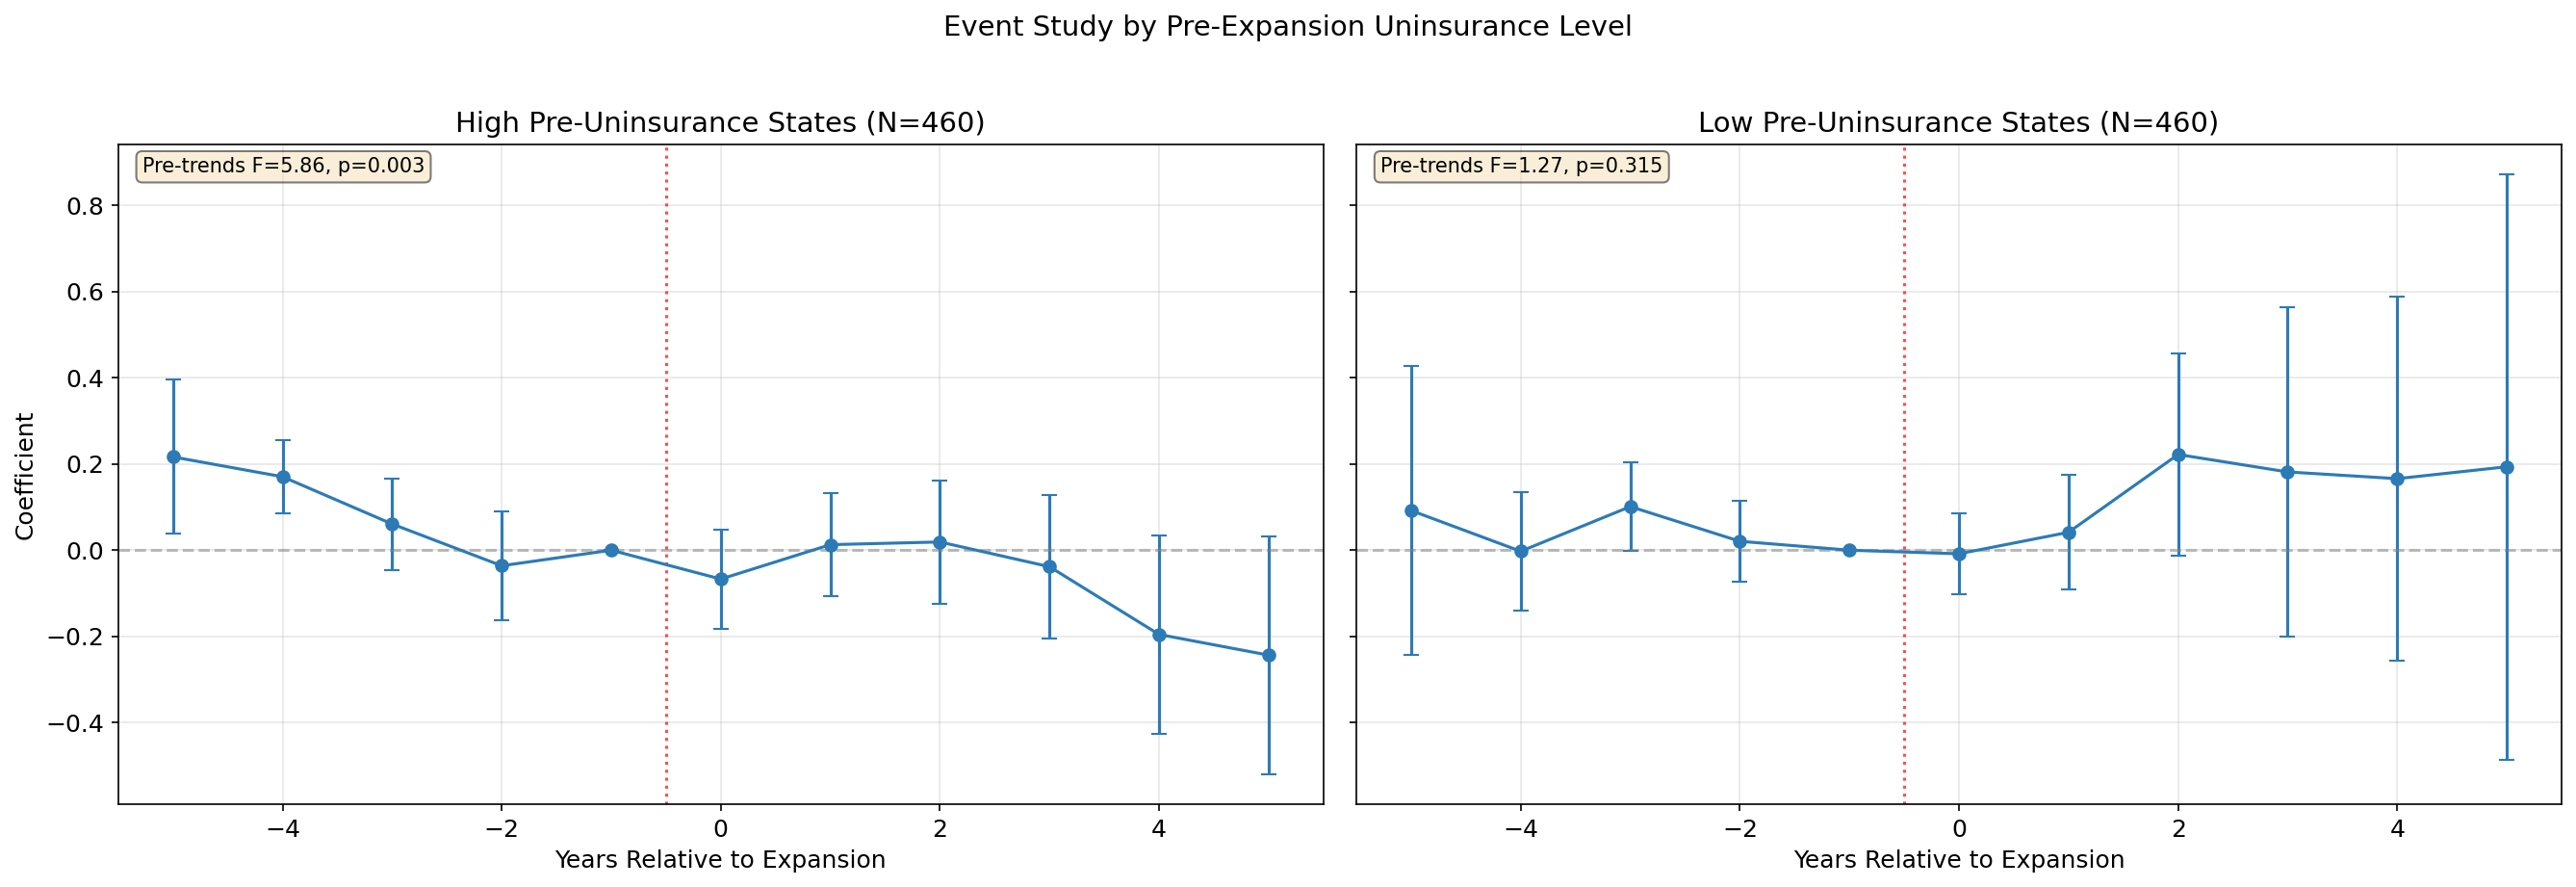

In [36]:
# event study by dose group: do high-uninsurance states also have steeper pre-trends?
high_states = df[(df['expansion_year'].notna()) & (df['pre_unins'] > med_u)]['state'].unique()
low_states = df[(df['expansion_year'].notna()) & (df['pre_unins'] <= med_u)]['state'].unique()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, states, label in zip(axes, [high_states, low_states], ['High Pre-Uninsurance', 'Low Pre-Uninsurance']):
    sub = df[df['state'].isin(states)].dropna(subset=['mean_log_premium_exp']).copy()
    sub['et_bin'] = sub['event_time'].clip(-5, 5).astype(int)
    ref = -1
    ets = sorted(sub['et_bin'].unique())
    for et in ets:
        if et != ref:
            sub[f'et_{et}'] = (sub['et_bin'] == et).astype(int)
    et_cols = [f'et_{et}' for et in ets if et != ref]
    st_d = pd.get_dummies(sub['state'], prefix='st', drop_first=True, dtype=int)
    yr_d = pd.get_dummies(sub['year'], prefix='yr', drop_first=True, dtype=int)
    X = sm.add_constant(pd.concat([sub[et_cols], st_d, yr_d], axis=1))
    groups = sub['state'].astype('category').cat.codes
    model = sm.OLS(sub['mean_log_premium_exp'], X).fit(cov_type='cluster', cov_kwds={'groups': groups})

    coefs = []
    for et in ets:
        if et == ref:
            coefs.append({'et': et, 'c': 0, 'lo': 0, 'hi': 0})
        else:
            col = f'et_{et}'
            coefs.append({'et': et, 'c': model.params[col],
                          'lo': model.conf_int().loc[col, 0], 'hi': model.conf_int().loc[col, 1]})
    cdf = pd.DataFrame(coefs)

    # pre-trends F
    pre_cols = [f'et_{et}' for et in ets if et < 0 and et != ref]
    if pre_cols:
        r_mat = np.zeros((len(pre_cols), len(model.params)))
        for i, col in enumerate(pre_cols):
            r_mat[i, list(model.params.index).index(col)] = 1
        ft = model.f_test(r_mat)
        f_s, f_p = float(ft.fvalue), float(ft.pvalue)
    else:
        f_s, f_p = np.nan, np.nan

    ax.errorbar(cdf['et'], cdf['c'], yerr=[cdf['c']-cdf['lo'], cdf['hi']-cdf['c']],
                fmt='o-', capsize=4, color='#2c7bb6', markersize=6)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(-0.5, color='red', linestyle=':', alpha=0.7)
    ax.set_xlabel('Years Relative to Expansion')
    ax.set_title(f'{label} States (N={len(sub)})')
    ax.text(0.02, 0.98, f'Pre-trends F={f_s:.2f}, p={f_p:.3f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.grid(True, alpha=0.3)
    print(f'{label}: pre-trends F={f_s:.3f}, p={f_p:.4f}')

axes[0].set_ylabel('Coefficient')
plt.suptitle('Event Study by Pre-Expansion Uninsurance Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../Results/figures/event_study_by_dose.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Placebo Test

Fake expansion in 2008 using only pre-2014 data. Should be null.

N=250, years 2009-2013
GBR: coef=-0.1871, SE=0.0608, p=0.0021 ***
Lasso: coef=-0.2645, SE=0.0864, p=0.0022 ***


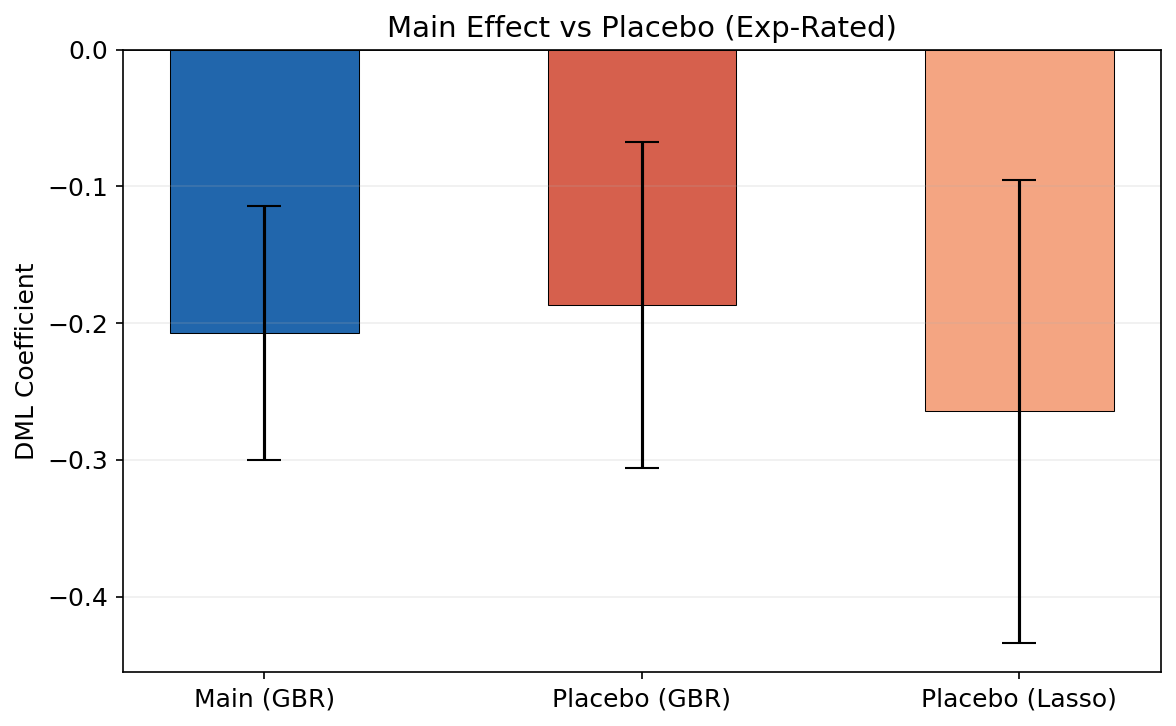

NonExp GBR: coef=0.0425, SE=0.0252, p=0.0918 *
NonExp Lasso: coef=0.1088, SE=0.0231, p=0.0000 ***


In [37]:
df_pre = df[df['year'] < 2014].copy()
exp_states = df[df['expansion_year'].notna()]['state'].unique()
df_pre['fake_expansion'] = ((df_pre['year'] >= 2008) & df_pre['state'].isin(exp_states)).astype(int)

pre_yr_cols = [c for c in df_pre.columns if c.startswith('year_') and df_pre[c].sum() > 0]
plac_x = [c for c in covariate_cols + pre_yr_cols if c in df_pre.columns]
plac_df = df_pre.dropna(subset=['mean_log_premium_exp', 'fake_expansion'] + plac_x)
print(f'N={len(plac_df)}, years {plac_df["year"].min()}-{plac_df["year"].max()}')

dml_plac_data = dml.DoubleMLData(plac_df, y_col='mean_log_premium_exp', d_cols='fake_expansion', x_cols=plac_x)

placebo_results = {}
for name, ml_l, ml_m in [
    ('GBR', GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, min_samples_leaf=10, random_state=42),
           GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, min_samples_leaf=10, random_state=42)),
    ('Lasso', Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))]),
             Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))])),
]:
    try:
        np.random.seed(42)  # reproducible DML cross-fitting
        m = dml.DoubleMLPLR(dml_plac_data, ml_l=ml_l, ml_m=ml_m, n_folds=5, n_rep=5, score='partialling out')
        m.fit()
        placebo_results[name] = {'coef': m.coef[0], 'se': m.se[0], 'pval': m.pval[0]}
        sig = '***' if m.pval[0] < 0.01 else '**' if m.pval[0] < 0.05 else '*' if m.pval[0] < 0.1 else ''
        print(f'{name}: coef={m.coef[0]:.4f}, SE={m.se[0]:.4f}, p={m.pval[0]:.4f} {sig}')
    except Exception as e:
        print(f'{name}: failed - {e}')

# plot: main vs placebo
main_gbr = results_med_exp.get('GBR', {})
plac_gbr = placebo_results.get('GBR', {})
plac_las = placebo_results.get('Lasso', {})
fig, ax = plt.subplots(figsize=(8, 5))
labs = ['Main (GBR)', 'Placebo (GBR)', 'Placebo (Lasso)']
cs = [main_gbr.get('coef', 0), plac_gbr.get('coef', 0), plac_las.get('coef', 0)]
ss = [main_gbr.get('se', 0), plac_gbr.get('se', 0), plac_las.get('se', 0)]
ax.bar(labs, cs, yerr=[1.96*s for s in ss], color=['#2166ac', '#d6604d', '#f4a582'],
       capsize=8, edgecolor='black', linewidth=0.5, width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('DML Coefficient')
ax.set_title('Main Effect vs Placebo (Exp-Rated)')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('../Results/figures/placebo_test.png', dpi=150, bbox_inches='tight')
plt.show()

# non-experience-rated placebo
plac_df_ne = df_pre.dropna(subset=['mean_log_premium_nonexp', 'fake_expansion'] + plac_x)
dml_plac_ne = dml.DoubleMLData(plac_df_ne, y_col='mean_log_premium_nonexp', d_cols='fake_expansion', x_cols=plac_x)
placebo_ne = {}
for name, ml_l, ml_m in [
    ('GBR', GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, min_samples_leaf=10, random_state=42),
           GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, min_samples_leaf=10, random_state=42)),
    ('Lasso', Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))]),
             Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5, random_state=42))])),
]:
    try:
        np.random.seed(42)  # reproducible DML cross-fitting
        m = dml.DoubleMLPLR(dml_plac_ne, ml_l=ml_l, ml_m=ml_m, n_folds=5, n_rep=5, score='partialling out')
        m.fit()
        placebo_ne[name] = {'coef': m.coef[0], 'se': m.se[0], 'pval': m.pval[0]}
        sig = '***' if m.pval[0] < 0.01 else '**' if m.pval[0] < 0.05 else '*' if m.pval[0] < 0.1 else ''
        print(f'NonExp {name}: coef={m.coef[0]:.4f}, SE={m.se[0]:.4f}, p={m.pval[0]:.4f} {sig}')
    except Exception as e:
        print(f'NonExp {name}: failed - {e}')

## 12. Summary: Primary (Within-State) and Pooled Results

In [38]:
print("DML + State FE")
for label, r in [('Exp-Rated', results_exp_primary), ('NonExp-Rated', results_nonexp_primary)]:
    for ln in ['RF', 'GBR', 'Lasso']:
        v = r.get(ln, {})
        sig = '***' if v.get('pval',1)<0.01 else '**' if v.get('pval',1)<0.05 else '*' if v.get('pval',1)<0.1 else ''
        print(f'  {label} {ln}: {v.get("coef",np.nan):.4f} (SE={v.get("se",np.nan):.4f}, p={v.get("pval",np.nan):.4f}) {sig}')

print("\nDML Pooled")
for label, r in [('Exp-Rated', results_exp_pooled), ('NonExp-Rated', results_nonexp_pooled)]:
    for ln in ['RF', 'GBR', 'Lasso']:
        v = r.get(ln, {})
        sig = '***' if v.get('pval',1)<0.01 else '**' if v.get('pval',1)<0.05 else '*' if v.get('pval',1)<0.1 else ''
        print(f'  {label} {ln}: {v.get("coef",np.nan):.4f} (SE={v.get("se",np.nan):.4f}, p={v.get("pval",np.nan):.4f}) {sig}')

print("\nTWFE")
for label, m in [('Exp-Rated', twfe_exp_dml), ('NonExp-Rated', twfe_nonexp_dml)]:
    print(f'  {label}: {m.params["medicaid_expansion"]:.4f} (SE={m.bse["medicaid_expansion"]:.4f}, p={m.pvalues["medicaid_expansion"]:.4f})')

print("\nMechanism")
print(f'  Uninsurance: {dml_unins.coef[0]:.4f} (p={dml_unins.pval[0]:.4f})')
if dose_results:
    for k, v in dose_results.items():
        print(f'  Dose ({k}): {v["coef"]:.4f} (p={v["pval"]:.4f})')
for k, v in placebo_results.items():
    print(f'  Placebo {k}: {v["coef"]:.4f} (p={v["pval"]:.4f})')

DML + State FE
  Exp-Rated RF: -0.2165 (SE=0.0584, p=0.0002) ***
  Exp-Rated GBR: -0.0719 (SE=0.0513, p=0.1607) 
  Exp-Rated Lasso: -0.1067 (SE=0.0411, p=0.0094) ***
  NonExp-Rated RF: 0.0073 (SE=0.0177, p=0.6815) 
  NonExp-Rated GBR: 0.0113 (SE=0.0150, p=0.4521) 
  NonExp-Rated Lasso: -0.0248 (SE=0.0127, p=0.0500) **

DML Pooled
  Exp-Rated RF: -0.2665 (SE=0.0561, p=0.0000) ***
  Exp-Rated GBR: -0.2072 (SE=0.0475, p=0.0000) ***
  Exp-Rated Lasso: -0.3057 (SE=0.0585, p=0.0000) ***
  NonExp-Rated RF: 0.0115 (SE=0.0181, p=0.5254) 
  NonExp-Rated GBR: -0.0034 (SE=0.0158, p=0.8296) 
  NonExp-Rated Lasso: 0.0262 (SE=0.0224, p=0.2417) 

TWFE
  Exp-Rated: -0.1176 (SE=0.0585, p=0.0444)
  NonExp-Rated: -0.0468 (SE=0.0215, p=0.0291)

Mechanism
  Uninsurance: -1.6088 (p=0.0000)
  Dose (High pre-unins): -0.2607 (p=0.0000)
  Dose (Low pre-unins): -0.0693 (p=0.3085)
  Placebo GBR: -0.1871 (p=0.0021)
  Placebo Lasso: -0.2645 (p=0.0022)


Results discussed in paper.